In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
from sklearn.preprocessing import StandardScaler,RobustScaler,OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV


In [2]:
df = pd.read_csv("AB_NYC_2019.csv")

In [3]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


1.Dropping id, host_id and host_name as they don't contribute to the final prediction

In [4]:
df.drop(columns=['id','host_id','host_name'], inplace=True)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            48879 non-null  object 
 1   neighbourhood_group             48895 non-null  object 
 2   neighbourhood                   48895 non-null  object 
 3   latitude                        48895 non-null  float64
 4   longitude                       48895 non-null  float64
 5   room_type                       48895 non-null  object 
 6   price                           48895 non-null  int64  
 7   minimum_nights                  48895 non-null  int64  
 8   number_of_reviews               48895 non-null  int64  
 9   last_review                     38843 non-null  object 
 10  reviews_per_month               38843 non-null  float64
 11  calculated_host_listings_count  48895 non-null  int64  
 12  availability_365                

In [7]:
df.isnull().sum()

name                                 16
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [8]:
df.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [9]:
# Drop rows where the listing name is missing
df = df.dropna(subset=['name'])

In [10]:
df['last_review'] = pd.to_datetime(df['last_review'])
reference_date = df['last_review'].max()
df['days_since_last_review'] = (reference_date - df['last_review']).dt.days

In [11]:
# number of rows above 365
extreme_rows = (df['minimum_nights'] > 365).sum()
percentage = (extreme_rows / len(df)) * 100

print(
    f"Total rows above 365 nights: {extreme_rows} "
    f"({percentage:.2f}% of the dataset)"
)


Total rows above 365 nights: 13 (0.03% of the dataset)


In [12]:
# Drop anomalous zero-price listings and cap minimum nights to 1 year
df = df[df['price'] > 0]
df = df[df['minimum_nights'] <= 365]
# Host Type 
df['host_type'] = df['calculated_host_listings_count'].apply(lambda x: 'Multi-listing' if x > 1 else 'Single-listing')

# Location-Based Distances (Haversine)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat / 2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

manhattan_center = (40.7580, -73.9855)
jfk_airport = (40.6413, -73.7781)
df['distance_to_center'] = df.apply(lambda row: haversine(row['latitude'], row['longitude'], manhattan_center[0], manhattan_center[1]), axis=1)
df['distance_to_jfk'] = df.apply(lambda row: haversine(row['latitude'], row['longitude'], jfk_airport[0], jfk_airport[1]), axis=1)

# Availability Bucketing
bins = [-1, 0, 90, 200, 365]
labels = ['Zero', 'Low', 'Medium', 'High']
df['availability_bucket'] = pd.cut(df['availability_365'], bins=bins, labels=labels)

#minimum nights
df['minimum_nights_bucket'] = pd.cut(
    df['minimum_nights'],
    bins=[0, 3, 14, np.inf],
    labels=['short', 'medium', 'long']
)

df['room_type_neighbourhood'] = df['room_type'] + '_' + df['neighbourhood_group']

In [13]:
df.head()

,name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,days_since_last_review,host_type,distance_to_center,distance_to_jfk,availability_bucket,minimum_nights_bucket,room_type_neighbourhood
0,Clean & quiet apt home by the park,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,262.0,Multi-listing,12.337898,16.405201,High,short,Private room_Brooklyn
1,Skylit Midtown Castle,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,48.0,Multi-listing,0.508366,21.368633,High,short,Entire home/apt_Manhattan
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365,NaN,Single-listing,6.757240,23.202089,High,short,Private room_Manhattan
3,Cozy Entire Floor of Brownstone,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,3.0,Single-listing,8.387034,16.079270,Medium,short,Entire home/apt_Brooklyn
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,231.0,Single-listing,5.701496,22.383848,Zero,medium,Entire home/apt_Manhattan


In [17]:
df.drop(columns=["last_review","calculated_host_listings_count"],inplace=True)

In [18]:
df.head()

,name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,days_since_last_review,host_type,distance_to_center,distance_to_jfk,availability_bucket,minimum_nights_bucket,room_type_neighbourhood
0,Clean & quiet apt home by the park,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,365,262.0,Multi-listing,12.337898,16.405201,High,short,Private room_Brooklyn
1,Skylit Midtown Castle,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,355,48.0,Multi-listing,0.508366,21.368633,High,short,Entire home/apt_Manhattan
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,365,NaN,Single-listing,6.757240,23.202089,High,short,Private room_Manhattan
3,Cozy Entire Floor of Brownstone,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,194,3.0,Single-listing,8.387034,16.079270,Medium,short,Entire home/apt_Brooklyn
4,Entire Apt: Spacious Studio/Loft by central park,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,0,231.0,Single-listing,5.701496,22.383848,Zero,medium,Entire home/apt_Manhattan


# EDA

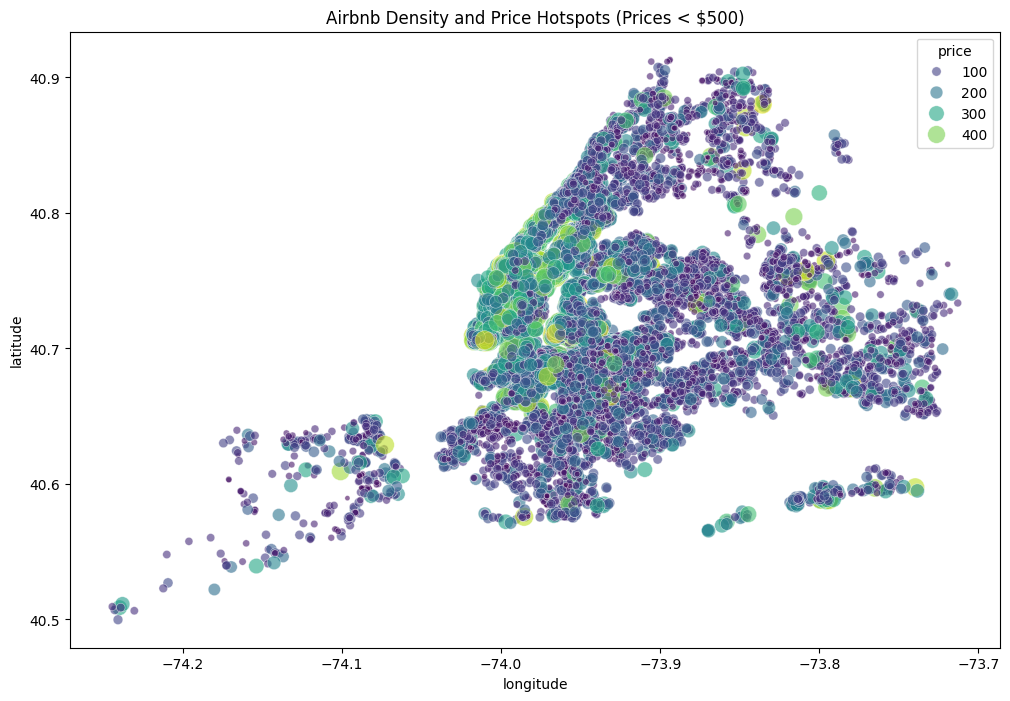

In [19]:
# Visualizing Geographic Pricing Hotspots
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='longitude', y='latitude', 
    hue='price', size='price', sizes=(10, 200), 
    palette='viridis', data=df[df['price'] < 500], alpha=0.6
)
plt.title('Airbnb Density and Price Hotspots (Prices < $500)')
plt.show()

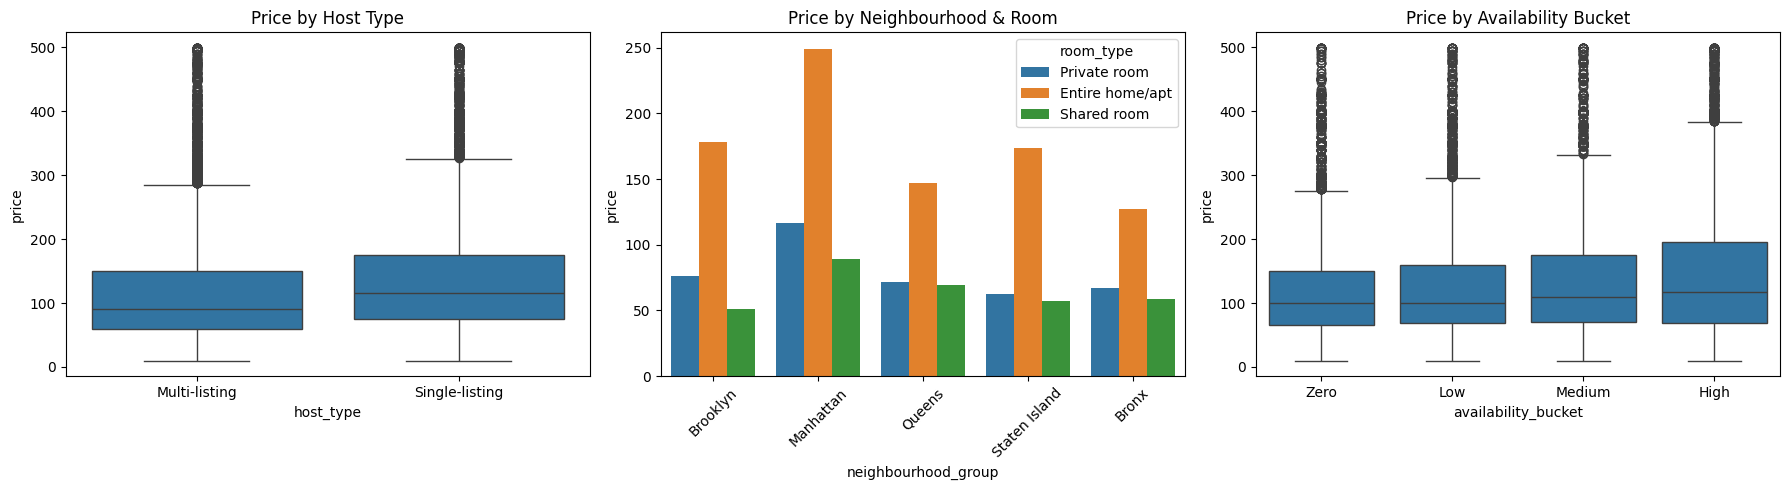

In [20]:
# Visualizing Engineered Features vs Price
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(x='host_type', y='price', data=df[df['price'] < 500], ax=axes[0])
axes[0].set_title('Price by Host Type')

sns.barplot(x='neighbourhood_group', y='price', hue='room_type', data=df, errorbar=None, ax=axes[1])
axes[1].set_title('Price by Neighbourhood & Room')
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(x='availability_bucket', y='price', data=df[df['price'] < 500], ax=axes[2])
axes[2].set_title('Price by Availability Bucket')

plt.tight_layout()
plt.show()

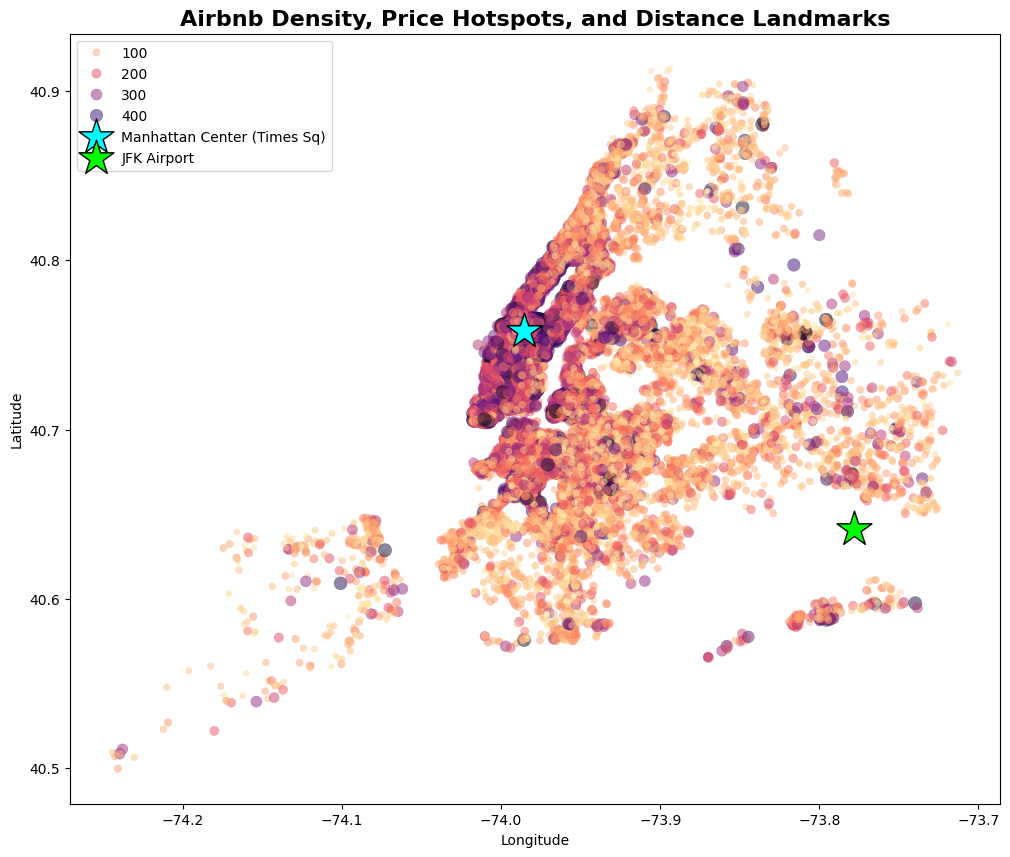

In [21]:
# Filter outliers out temporarily so the color map scales nicely
viz_df = df[(df['price'] > 0) & (df['price'] < 500)]

plt.figure(figsize=(12, 10))

# Scatter plot using latitude and longitude
sns.scatterplot(
    x='longitude', y='latitude',
    hue='price', palette='magma_r',
    size='price', sizes=(10, 100),
    data=viz_df, alpha=0.5, edgecolor=None
)

# Plotting our custom location features
manhattan_center = (-73.9855, 40.7580) # (longitude, latitude)
jfk_airport = (-73.7781, 40.6413)

plt.scatter(manhattan_center[0], manhattan_center[1], color='cyan', marker='*', s=700, label='Manhattan Center (Times Sq)', edgecolor='black')
plt.scatter(jfk_airport[0], jfk_airport[1], color='lime', marker='*', s=700, label='JFK Airport', edgecolor='black')

plt.title('Airbnb Density, Price Hotspots, and Distance Landmarks', fontsize=16, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

# Preprocessing

In [22]:
X = df.drop(columns=['price', 'availability_365', 'minimum_nights'])
# Apply log1p to target to fix severe right-skewness
y = np.log1p(df['price']) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (39084, 15), Test shape: (9771, 15)


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, TargetEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import BaseEstimator, TransformerMixin

# Define feature groups
num_features = ['latitude', 'longitude', 'number_of_reviews', 'reviews_per_month', 
                'days_since_last_review', 
                'distance_to_center', 'distance_to_jfk']

cat_features_ohe = ['neighbourhood_group', 'room_type', 'host_type', 
                    'availability_bucket', 'minimum_nights_bucket', 'room_type_neighbourhood']

cat_features_target = ['neighbourhood'] 
text_feature = 'name'

# 1. Numeric: Iterative imputation for missing reviews + RobustScaler for extreme outliers
num_transformer = Pipeline(steps=[
    ('imputer', IterativeImputer(max_iter=10, random_state=42)),
    ('scaler', RobustScaler())
])

# 2. Categorical (Low Cardinality): One-Hot Encoding
cat_ohe_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. Categorical (High Cardinality): Target Encoding (native sklearn)
cat_target_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_enc', TargetEncoder(smooth="auto"))
])

# 4. Text: TF-IDF Extraction (Top 50 words)
class FillNaWrapper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X): return X.fillna('')

text_transformer = Pipeline(steps=[
    ('fillna', FillNaWrapper()),
    ('tfidf', TfidfVectorizer(max_features=50, stop_words='english'))
])

# 5. Finalize ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat_ohe', cat_ohe_transformer, cat_features_ohe),
        ('cat_target', cat_target_transformer, cat_features_target),
        ('text', text_transformer, text_feature)
    ],
    remainder='drop'
)

# Fit pipeline on training data
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)
print(f"Processed Train Shape: {X_train_processed.shape}")

Processed Train Shape: (39084, 90)


In [27]:
import joblib

joblib.dump(X_train_processed, 'X_train_processed.pkl')
joblib.dump(X_test_processed, 'X_test_processed.pkl')
joblib.dump(y_train, 'y_train.pkl')
joblib.dump(y_test, 'y_test.pkl')

joblib.dump(preprocessor, 'preprocessor_pipeline.pkl')

print("All processed datasets and preprocessor saved successfully!")

All processed datasets and preprocessor saved successfully!
